In [1]:
import ipywidgets as widgets

In [2]:
from ipywebrtc import VideoStream
# https://gist.github.com/jsturgis/3b19447b304616f18657
# video = VideoStream.from_url('http://commondatastorage.googleapis.com/gtv-videos-bucket/sample/BigBuckBunny.mp4')
video = VideoStream.from_file('./BigBuckBunny.mp4')
video

FileNotFoundError: [Errno 2] No such file or directory: './BigBuckBunny.mp4'

In [3]:
from ipywebrtc import WidgetStream
video_stream = WidgetStream(widget=video, max_fps=1)
video_stream

NameError: name 'video' is not defined

In [38]:
from ipywidgets import FloatSlider
slider = FloatSlider(
    value=7.5,
    step=0.1,
    description='Test:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)
slider

FloatSlider(value=7.5, continuous_update=False, description='Test:', readout_format='.1f')

In [39]:
from ipywebrtc import WidgetStream
widget_stream = WidgetStream(widget=slider, max_fps=1)
widget_stream

WidgetStream(max_fps=1, widget=FloatSlider(value=7.5, continuous_update=False, description='Test:', readout_fo…

In [5]:
widget_stream.close()

In [11]:
from ipywebrtc import ImageRecorder
image_recorder = ImageRecorder(stream=widget_stream)
image_recorder

ImageRecorder(image=Image(value=b''), stream=WidgetStream(max_fps=1, widget=FloatSlider(value=7.5, continuous_…

In [13]:
image_recorder.image

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02X\x00\x00\x008\x08\x06\x00\x00\x00!\r\x86\xaf\x00…

In [14]:
image_recorder.recording = True
image_recorder.autosave = False
image_recorder.download()
image_recorder.image.height

'56px'

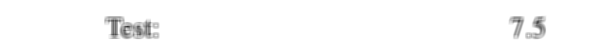

In [17]:
import PIL.Image
import PIL.ImageFilter
import io
im = PIL.Image.open(io.BytesIO(image_recorder.image.value))
im.filter(PIL.ImageFilter.BLUR)

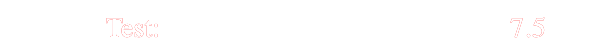

In [19]:
import numpy as np
im_array = np.array(im)
im_array
PIL.Image.fromarray(im_array[...,::-1])

In [17]:
from skimage.filters import roberts, sobel, scharr, prewitt
from skimage.color import rgb2gray
from skimage.color.adapt_rgb import adapt_rgb, each_channel, hsv_value
from skimage import filters

image = widgets.Image()
output = widgets.Output()
filter_options = [('roberts', roberts), ('sobel', sobel), ('scharr', scharr), ('prewitt', prewitt)]
filter_widget = widgets.ToggleButtons(options=filter_options)

@output.capture()
def update_image(change):
    # turn into nparray
    im_in = PIL.Image.open(io.BytesIO(image_recorder.image.value))
    im_array = np.array(im_in)[...,:3] # no alpha

    # filter
    filter_function = filter_widget.value
    im_array_edges = adapt_rgb(each_channel)(filter_function)(im_array)
    im_array_edges = ((1-im_array_edges) * 255).astype(np.uint8)
    im_out = PIL.Image.fromarray(im_array_edges)

    # store in image widget
    f = io.BytesIO()
    im_out.save(f, format='png')
    image.value = f.getvalue()

image_recorder.image.observe(update_image, 'value')
filter_widget.observe(update_image, 'value')
widgets.VBox([filter_widget, video, widgets.HBox([image_recorder, image]), output])

NameError: name 'video' is not defined

In [5]:
import ipywidgets as widgets
out = widgets.Output(layout={'border': '1px solid black', 'width': '500px'})
out

Output(layout=Layout(border='1px solid black', width='500px'))

In [6]:
from IPython.display import YouTubeVideo
with out:
    import ipymaterialui as m
    display(m.Chip(label=['Hello']))

In [25]:
import ipymaterialui as m
c = m.Chip(label=['Hello'])
c

Chip(label=['Hello'])

In [24]:
from ipywebrtc import WidgetStream
widget_stream = WidgetStream(widget=out, max_fps=1)
widget_stream

WidgetStream(max_fps=1, widget=Output(layout=Layout(border='1px solid black', width='500px'), outputs=({'outpu…

In [8]:
out_stream = WidgetStream(widget=out)
out_stream

WidgetStream(widget=Output(layout=Layout(border='1px solid black', width='500px'), outputs=({'output_type': 'd…

In [9]:
from ipywebrtc import ImageRecorder
image_recorder = ImageRecorder(stream=out_stream)
image_recorder

ImageRecorder(image=Image(value=b''), stream=WidgetStream(widget=Output(layout=Layout(border='1px solid black'…

In [10]:
from ipyleaflet import Map
m = Map(center=(46, 14), zoom=5)
m

Map(basemap={'url': 'https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', 'max_zoom': 19, 'attribution': 'Map …

In [15]:
map_stream = WidgetStream(widget=m, max_fps=1)
map_stream

WidgetStream(max_fps=1, widget=Map(basemap={'url': 'https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', 'max_…

In [18]:
from ipywebrtc import ImageRecorder
image_recorder = ImageRecorder(stream=map_stream)
image_recorder

ImageRecorder(image=Image(value=b''), stream=WidgetStream(max_fps=1, widget=Map(basemap={'url': 'https://{s}.t…

In [ ]:
map_stream.close()